In [2]:
import jax.numpy as jnp

In [156]:
import ase
import ase.io as ase_io
import ase.visualize.plot
traj_x = ase_io.read("ell4_100x.traj", index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")

In [157]:
len(traj_x)

10002

<Axes: >

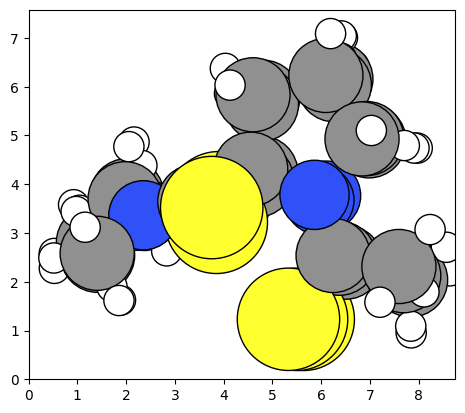

In [158]:
from ase.visualize.plot import plot_atoms as plot_atoms

plot_atoms(traj_x[0])
plot_atoms(traj_x[3000])
plot_atoms(traj_x[4000])

<Axes: >

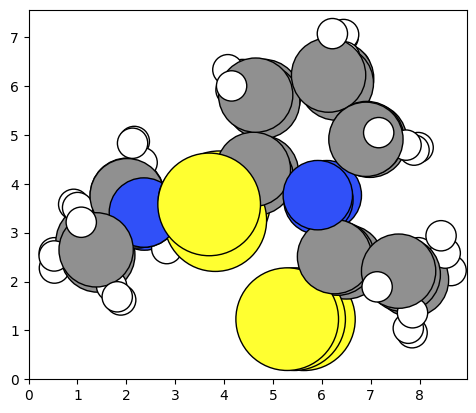

In [166]:
plot_atoms(traj_xn[0])
plot_atoms(traj_xn[3000])
plot_atoms(traj_xn[4000])

<Axes: >

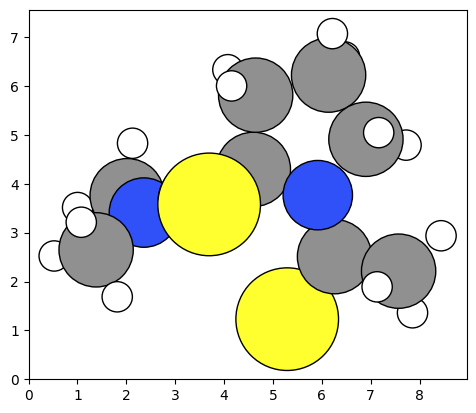

In [257]:
plot_atoms(traj_xn[4000])

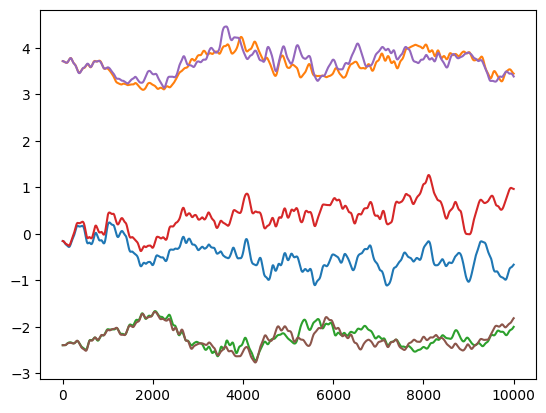

In [165]:
dipm = [_.get_dipole_moment() for _ in traj_x]
xdipm = [_.get_dipole_moment() for _ in traj_xn]
dipm


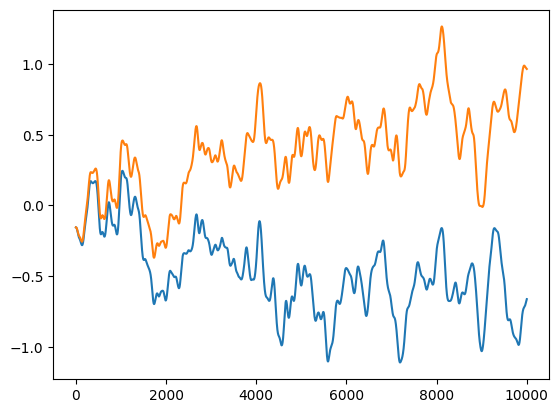

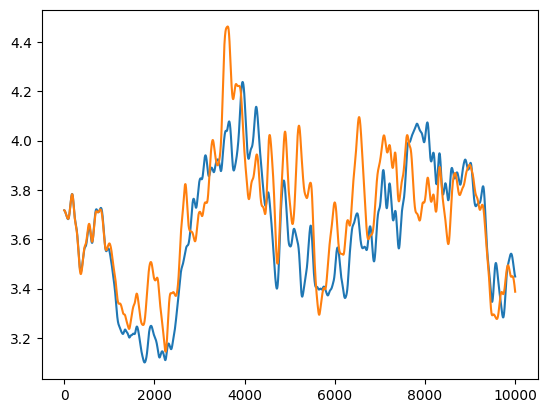

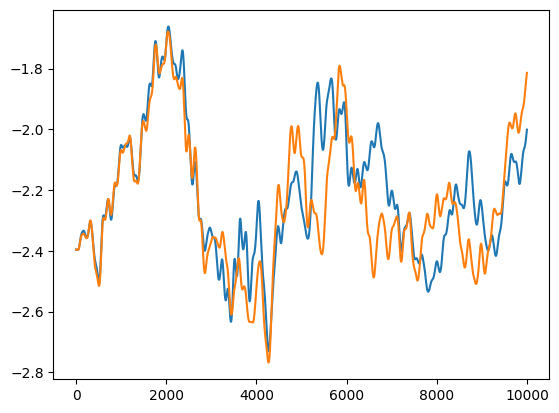

In [256]:
dipm = np.array(dipm)
xdipm = np.array(xdipm)
for i in range(3):
    plt.plot(dipm[:,i])
    plt.plot(xdipm[:,i]
            )
    plt.show()

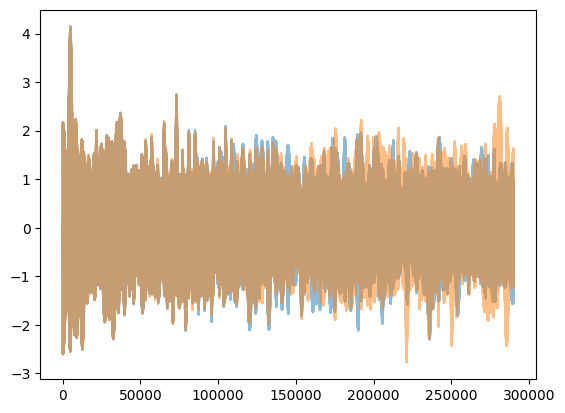

In [174]:
forces = np.array([_.get_forces() for _ in traj_x])
xforces = np.array([_.get_forces() for _ in traj_xn])#, alpha=0.5)
plt.plot(forces.reshape(-1,3)[:,0], alpha=0.5)
plt.plot(xforces.reshape(-1,3)[:,0], alpha=0.5)

(array([3.20000e+02, 3.15000e+03, 2.10070e+04, 1.13377e+05, 1.20643e+05,
        2.27730e+04, 3.45100e+03, 3.05000e+02, 1.10000e+01, 2.10000e+01]),
 array([-2.77398086, -2.08390737, -1.39383388, -0.70376039, -0.0136869 ,
         0.67638659,  1.36646008,  2.05653358,  2.74660707,  3.43668056,
         4.12675381]),
 <BarContainer object of 10 artists>)

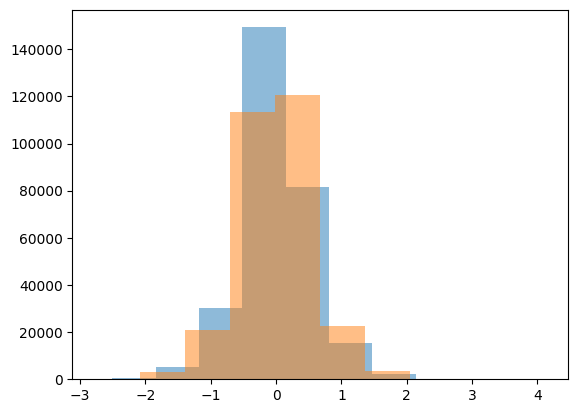

In [178]:
plt.hist(forces.reshape(-1,3)[5000:,0], alpha=0.5)
plt.hist(xforces.reshape(-1,3)[5000:,0], alpha=0.5)

In [261]:
traj_x[100].info

{'electric_field': array([0.1980198, 0.       , 0.       ]),
 'ml_dipole': array([-0.25042185,  3.6867163 , -2.357787  ], dtype=float32)}

In [179]:
import numpy as np
from ase.io import read, write

def kabsch_align(mobile_xyz, ref_xyz):
    """Return mobile_xyz rigidly aligned to ref_xyz (same atom order)."""
    # Remove COM
    mob_com = mobile_xyz.mean(axis=0)
    ref_com = ref_xyz.mean(axis=0)
    X = mobile_xyz - mob_com
    Y = ref_xyz - ref_com

    # Kabsch rotation
    C = X.T @ Y
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    D = np.diag([1.0, 1.0, d])
    R = V @ D @ Wt

    # Rotate + translate onto reference COM
    X_aligned = X @ R
    return X_aligned + ref_com

def rmsd(a, b):
    return np.sqrt(np.mean(np.sum((a - b) ** 2, axis=1)))

traj_x = ase_io.read("ell4_100x.traj", index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")
# Read all frames from an ASE trajectory-like file (.traj, .xyz, etc.)
frames = traj_x #read("traj.traj", index=":")
frames2 = traj_xn
ref = frames[0].copy()

# Optional: align only a subset (e.g. heavy atoms)
# sel = [i for i, Z in enumerate(ref.get_atomic_numbers()) if Z > 1]
sel = np.arange(len(ref))

aligned_frames = []
aligned_frames2 = []
rmsd_values = []
rmsd_values2 = []

ref_sel = ref.positions[sel]
for at in frames:
    at2 = at.copy()
    pos = at2.positions.copy()
    pos_sel_aligned = kabsch_align(pos[sel], ref_sel)

    # Apply same rigid transform to ALL atoms:
    # recover transform from selected atoms
    mob_com = pos[sel].mean(axis=0)
    ref_com = ref_sel.mean(axis=0)
    X = pos[sel] - mob_com
    Y = ref_sel - ref_com
    V, S, Wt = np.linalg.svd(X.T @ Y)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt
    pos_aligned = (pos - mob_com) @ R + ref_com

    at2.positions = pos_aligned
    aligned_frames.append(at2)
    rmsd_values.append(rmsd(pos_aligned[sel], ref_sel))

for at in frames2:
    at2 = at.copy()
    pos = at2.positions.copy()
    pos_sel_aligned = kabsch_align(pos[sel], ref_sel)

    # Apply same rigid transform to ALL atoms:
    # recover transform from selected atoms
    mob_com = pos[sel].mean(axis=0)
    ref_com = ref_sel.mean(axis=0)
    X = pos[sel] - mob_com
    Y = ref_sel - ref_com
    V, S, Wt = np.linalg.svd(X.T @ Y)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt
    pos_aligned = (pos - mob_com) @ R + ref_com

    at2.positions = pos_aligned
    aligned_frames2.append(at2)
    rmsd_values2.append(rmsd(pos_aligned[sel], ref_sel))

write("traj_aligned.traj", aligned_frames)
print("First 10 RMSDs (A):", np.array(rmsd_values[:10]))

First 10 RMSDs (A): [1.77244295e-15 1.77244295e-15 2.43040387e-05 9.71789372e-05
 2.18513337e-04 3.88121584e-04 6.05743860e-04 8.71046447e-04
 1.18362196e-03 1.54298957e-03]


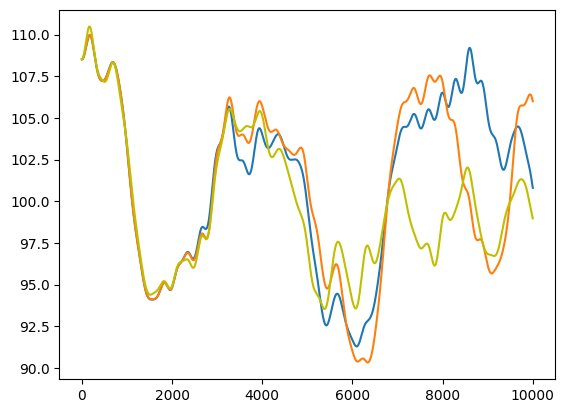

In [218]:

plot_atoms(traj_xn[4000])

traj_x = ase_io.read("ell4_100x.traj", index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")
R = np.array([_.get_positions() for _ in traj_x])
dihs_ = R[:,[0, 2, 9, 11],:]
out_dihs_trajx = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

R = np.array([_.get_positions() for _ in traj_xn])
dihs_ = R[:,[0, 2, 9, 11],:]
out_dihs_trajxn = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)
plt.plot(out_dihs_trajx)
plt.plot(out_dihs_trajxn)
plt.plot(out_dihs[:,0], color="y")
traj_x = ase_io.read("ell4_100x.traj", index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")
R = np.array([_.get_positions() for _ in traj_x])
dihs_ = R[:,[3, 4, 1, 0],:]
out_dihs_trajx = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

R = np.array([_.get_positions() for _ in traj_xn])
dihs_ = R[:,[3, 4, 1, 0],:]
out_dihs_trajxn = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

_ = jnp.load("ell4_100.npz")
R = _["R"]
dihs_ = R[:,:,[3, 4, 1, 0],:]
out_dihs2ell4_100 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 10,)



plt.plot(((out_dihs_trajx)) % 360)
plt.plot( (out_dihs_trajxn) % 360)
plt.plot((out_dihs2ell4_100[:,0]) % 360, color="y" )
plt.axhline(180)

dipm = np.array(dipm)
xdipm = np.array(xdipm)
for i in range(3):
    plt.plot(dipm[:,i])
    plt.plot(xdipm[:,i]
            )
    plt.show()


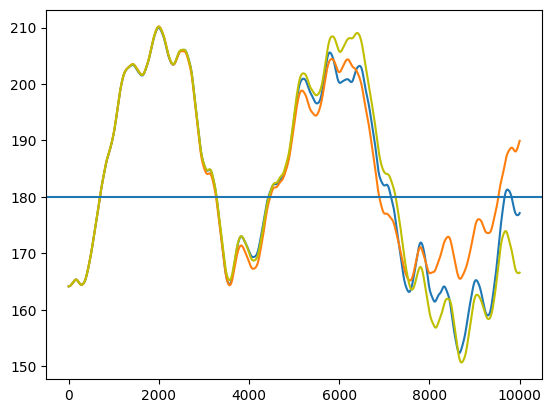

In [265]:
ef = np.array([ _.info["electric_field"] for _ in traj_x])
efx = np.array([_.info["electric_field"] for _ in traj_xn])

In [161]:
energies = [_.get_potential_energy() for _ in traj_x]
total_energies = [_.get_total_energy() for _ in traj_x]
kin_energies = [_.get_kinetic_energy() for _ in traj_x]
nenergies = [_.get_potential_energy() for _ in traj_xn]
ntotal_energies = [_.get_total_energy() for _ in traj_xn]
nkin_energies = [_.get_kinetic_energy() for _ in traj_xn]

In [5]:
ell4 = jnp.load("ell4.npz")

In [30]:
ell4["R"].shape

(10001, 10, 29, 3)

In [14]:
R = ell4["R"]
Z = ell4["Z"]
for i in range(len(Z)):
    print(i, Z[i])

0 16
1 6
2 7
3 6
4 6
5 6
6 6
7 6
8 6
9 7
10 6
11 16
12 6
13 1
14 1
15 1
16 1
17 1
18 1
19 1
20 1
21 1
22 1
23 1
24 1
25 1
26 1
27 1
28 1


In [45]:
import jax

def _norm(x: np.ndarray) -> float:
    return float(np.linalg.norm(x))

def dih(p,  eps=1e-12):
    # p: (4, 3)
    b0 = p[0] - p[1]
    b1 = p[2] - p[1]
    b2 = p[3] - p[2]

    b1n = b1 / jnp.maximum(jnp.linalg.norm(b1), eps)
    v = b0 - jnp.dot(b0, b1n) * b1n
    w = b2 - jnp.dot(b2, b1n) * b1n

    x = jnp.dot(v, w)
    y = jnp.dot(jnp.cross(b1n, v), w)
    angle = jnp.degrees(jnp.arctan2(y, x))  # already in [-180, 180]

    # Optional clamp logic kept to mirror your original function:
    angle = jnp.where(angle > 180.0, angle - 360.0, angle)
    angle = jnp.where(angle < -180.0, angle + 360.0, angle)
    return angle



# P: (N, 4, 3) -> angles: (N,)
batched_dih = jax.vmap(dih, in_axes=(0), out_axes=0)
# Optional JIT:batched_dih = jax.jit(batched_dih)


In [129]:
_ = jnp.load("ell0.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs0 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 30,)
_ = jnp.load("ell2.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs2 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 10,)

_ = jnp.load("ell4_100.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs2ell4_100 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 10,)

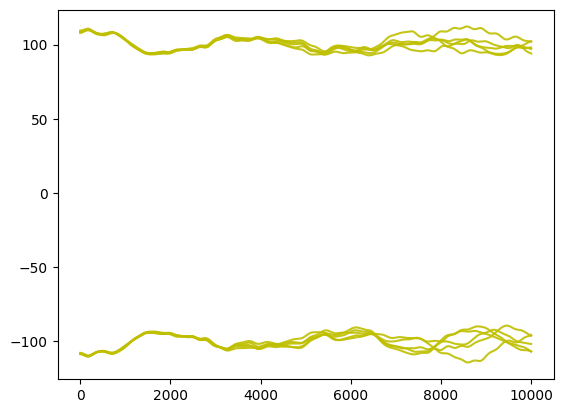

In [132]:
plt.plot(out_dihs2ell4_100, alpha=0.9, color="y")

In [106]:
out_dihs.min()

Array(-110.707596, dtype=float32)

In [107]:
out_dihs.max()

Array(110.62177, dtype=float32)

In [108]:
data_train = jnp.load("data-full.npz", allow_pickle=True)

In [109]:
data_train

NpzFile 'data-full.npz' with keys: R, Z, D, E, F...

In [136]:
data_train["R"]

array([[[[-0.856624, 0.129623, 1.934218],
         [-1.113226, 0.208861, 0.29253],
         [-2.395473, -0.129327, -0.244816],
         ...,
         [3.221661, -0.929147, 1.445703],
         [3.053021, -2.547992, 0.761525],
         [3.882805, -1.269515, -0.230995]]],


       [[[0.857171, 0.11295, 1.933472],
         [1.094587, 0.199589, 0.312627],
         [2.400773, -0.110526, -0.246986],
         ...,
         [-3.206281, -0.93495, 1.453658],
         [-3.863548, -1.29525, -0.211989],
         [-3.046018, -2.597426, 0.756026]]],


       [[[-0.842514, 0.134943, 1.931842],
         [-1.103519, 0.203674, 0.322082],
         [-2.397987, -0.138973, -0.239201],
         ...,
         [3.224724, -0.928305, 1.451876],
         [3.0758, -2.559792, 0.751777],
         [3.851699, -1.281191, -0.238558]]],


       ...,


       [[[0.872975, 0.118662, 1.943759],
         [1.101215, 0.199464, 0.304584],
         [2.404039, -0.13228, -0.257062],
         ...,
         [-3.2299, -0.927025, 1.452

In [120]:
R = jnp.array(data_train["R"], dtype=jnp.float32)
# R.dtype = 
R.shape, R.dtype

((10000, 1, 29, 3), dtype('float32'))

In [122]:
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs_data_train = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

In [125]:
out_dihs_data_train

Array([ 108.622314, -107.96623 ,  108.70798 , ..., -108.443985,
        108.519035, -109.068   ], dtype=float32)

/tmp/ipykernel_1112729/3754482291.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ts.set_xticklabels(xticks * dt)


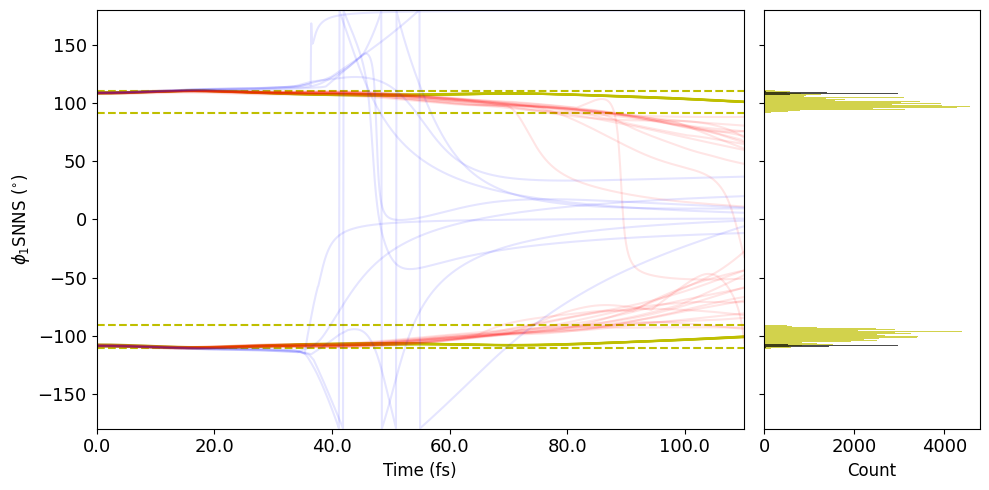

In [295]:
import matplotlib.pyplot as plt
import numpy as np

A, B = 120, 80

fig, (ax_ts, ax_hist) = plt.subplots(
    1, 2, figsize=(10, 5),
    gridspec_kw={"width_ratios": [3, 1]},
    sharey=True
)

# --- Time series ---
ax_ts.plot(out_dihs, color="y")
ax_ts.axhline(out_dihs[:,0::2].min(), color="y", linestyle="--")
ax_ts.axhline(out_dihs[:,0::2].max(), color="y", linestyle="--")
ax_ts.axhline(out_dihs[:,1::2].min(), color="y", linestyle="--")
ax_ts.axhline(out_dihs[:,1::2].max(), color="y", linestyle="--")

ax_ts.plot(out_dihs0, alpha=0.1, color="r")
ax_ts.plot(out_dihs2, alpha=0.1, color="b")
# ax_ts.plot(out_dihs2ell4_100, alpha=0.9, color="y")

ax_ts.set_xlim(0, 1100)
ax_ts.set_ylim(-180, 180)
ax_ts.set_xlabel("Frame")
ax_ts.set_ylabel("Dihedral angle (deg)")

# --- Horizontal histograms ---
bins = 50

ax_hist.hist(
    out_dihs.flatten(),
    bins=bins,
    range=(-A, -B),
    orientation="horizontal",
    color="y",
    alpha=0.7
)

ax_hist.hist(
    out_dihs.flatten(),
    bins=bins,
    range=(B, A),
    orientation="horizontal",
    color="y",
    alpha=0.7
)

ax_hist.hist(
    out_dihs_data_train.flatten(),
    bins=bins,
    range=(-A, -B),
    orientation="horizontal",
    color="k",
    alpha=0.7
)

ax_hist.hist(
    out_dihs_data_train.flatten(),
    bins=bins,
    range=(B, A),
    orientation="horizontal",
    color="k",
    alpha=0.7
)

ax_hist.set_xlabel("Count")
dt = 0.1
xticks = ax_ts.get_xticks()
ax_ts.set_xticklabels(xticks * dt)
ax_ts.set_xlabel("Time (fs)")
ax_ts.set_ylabel(r"$\phi_1 {\mathrm{SNNS}}\ (^{\circ})$")
plt.tight_layout()
plt.savefig("broken_sims.pdf", bbox_inches="tight")
plt.show()

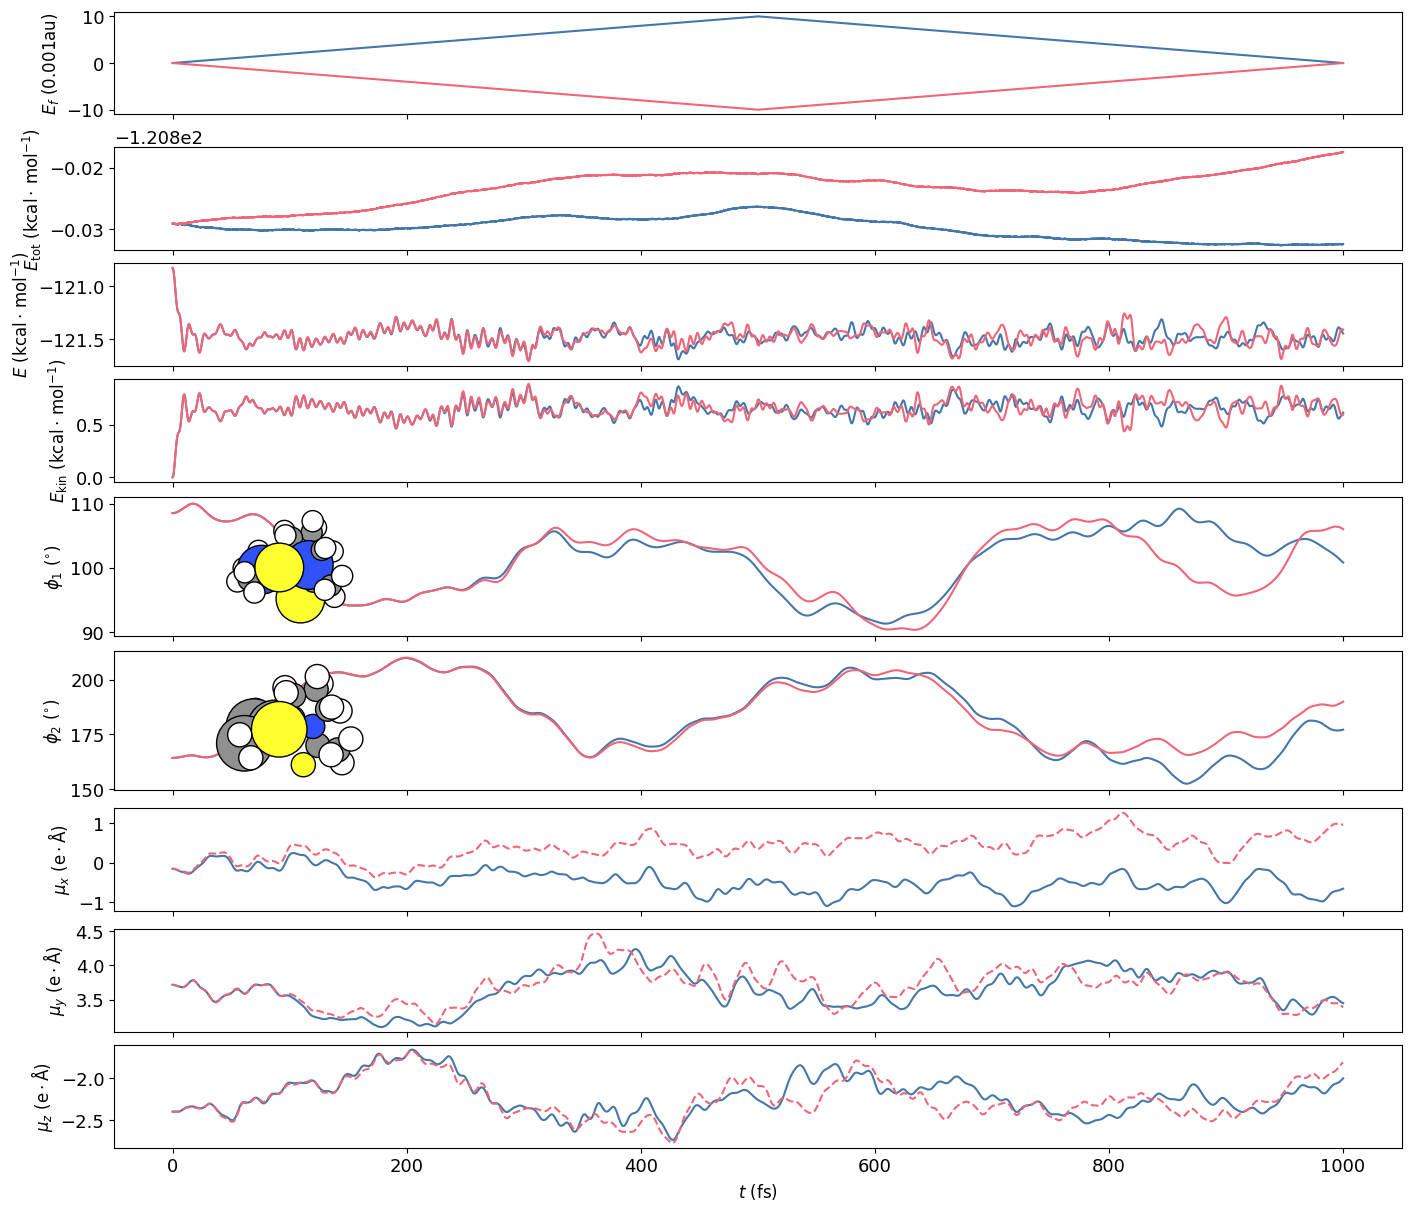

In [292]:
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -------------------------
# user-set units + timestep
# -------------------------
DT_FS = 0.1
EF_UNIT  = r'0.001 au'
E_UNIT = r'kcal\cdot\,mol^{-1}'         # e.g. r'eV', r'kcal\,mol^{-1}'
MU_UNIT = r'e\cdot\AA'                # e.g. r'D', r'e\AA'
PHI_UNIT = r'^{\circ}'                # usually 'deg'

# -------------------------
# style / cycle
# -------------------------
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB"]
)
plt.rcParams.update({
    "axes.labelsize": 12,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
c_x, c_xn, c_ref = cycle[0], cycle[1], cycle[2]

# -------------------------
# helpers
# -------------------------
def time_fs(n, dt_fs=DT_FS):
    return np.arange(n) * dt_fs

def dihedral_series_from_traj(traj, idx4):
    R = np.array([a.get_positions() for a in traj])
    dihs_ = R[:, idx4, :]
    return batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

def draw_atoms_highlight_selected(ax, atoms, idx4, base_r=0.80, highlight_scale=2.3,
                                 rotation=('0x,0y,0z')):
    radii = np.full(len(atoms), base_r, dtype=float)
    radii[list(idx4)] = base_r * highlight_scale
    plot_atoms(atoms, ax=ax, radii=radii, rotation=rotation)
    ax.set_axis_off()

# -------------------------
# load / compute series
# -------------------------
traj_x  = ase_io.read("ell4_100x.traj",  index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")

idx_d1 = (0, 2, 9, 11)
idx_d2 = (3, 4, 1, 0)

d1_x  = dihedral_series_from_traj(traj_x,  idx_d1)
d1_xn = dihedral_series_from_traj(traj_xn, idx_d1)

d2_x  = dihedral_series_from_traj(traj_x,  idx_d2)
d2_xn = dihedral_series_from_traj(traj_xn, idx_d2)

# reference (optional)
_ = jnp.load("ell4_100.npz")
R = _["R"]
dihs2_ = R[:, :, list(idx_d2), :]
d2_ref = batched_dih(dihs2_.reshape((-1, 4, 3))).reshape(-1, 10)[:, 0]

dipm  = np.array(dipm)
xdipm = np.array(xdipm)

atoms_example = traj_xn[4000]

# time axes (fs)
t_ef   = time_fs(len(ef))
t_E    = time_fs(len(energies))
t_Etot = time_fs(len(total_energies))
t_Ekin = time_fs(len(kin_energies))
t_d1   = time_fs(len(d1_x))
t_d2   = time_fs(len(d2_x))
t_mu   = time_fs(len(dipm))

# -------------------------
# mosaic (ASE overlays are insets in dihedral panels)
# -------------------------
mosaic = [
    ["ef",   "ef"],
    ["Etot", "Etot"],
    ["E",    "E"],
    ["Ekin", "Ekin"],
    ["phi1", "phi1"],
    ["phi2", "phi2"],
    ["mux",  "mux"],
    ["muy",  "muy"],
    ["muz",  "muz"],
]

fig = plt.figure(layout="constrained", figsize=(14, 12))
axd = fig.subplot_mosaic(
    mosaic,
    width_ratios=[1, 1],
    height_ratios=[1, 1, 1, 1, 1.35, 1.35, 1, 1, 1],
)

# share x across time-series panels
for k in ["Etot", "E", "Ekin", "phi1", "phi2", "mux", "muy", "muz"]:
    axd[k].sharex(axd["ef"])

# -------------------------
# energies
# -------------------------
axd["ef"].plot(t_ef, ef[:, 0],  color=c_x)
axd["ef"].plot(t_ef, efx[:, 0], color=c_xn)
axd["ef"].set_ylabel(rf'$E_f\ \mathrm{{({EF_UNIT})}}$')

axd["E"].plot(t_E, energies,  color=c_x)
axd["E"].plot(t_E, nenergies, color=c_xn)
axd["E"].set_ylabel(rf'$E\ \mathrm{{({E_UNIT})}}$')

axd["Etot"].plot(t_Etot, total_energies,  color=c_x)
axd["Etot"].plot(t_Etot, ntotal_energies, color=c_xn)
axd["Etot"].set_ylabel(rf'$E_{{\mathrm{{tot}}}}\ \mathrm{{({E_UNIT})}}$')

axd["Ekin"].plot(t_Ekin, kin_energies,  color=c_x)
axd["Ekin"].plot(t_Ekin, nkin_energies, color=c_xn)
axd["Ekin"].set_ylabel(rf'$E_{{\mathrm{{kin}}}}\ \mathrm{{({E_UNIT})}}$')

# -------------------------
# dihedrals + ASE insets (left side overlays)
# -------------------------
axd["phi1"].plot(t_d1, d1_x % 360,  color=c_x)
axd["phi1"].plot(t_d1, d1_xn % 360, color=c_xn)
axd["phi1"].set_ylabel(rf'$\phi_1\ \mathrm{{({PHI_UNIT})}}$')

ax_phi1_in = inset_axes(axd["phi1"], width="26%", height="85%",
                        loc="center left", borderpad=0.6)
draw_atoms_highlight_selected(ax_phi1_in, atoms_example, idx_d1, base_r=0.80, highlight_scale=2.3)

axd["phi2"].plot(t_d2, d2_x % 360,   color=c_x)
axd["phi2"].plot(t_d2, d2_xn % 360,  color=c_xn)
# optional ref:
# axd["phi2"].plot(t_d2[:len(d2_ref)], d2_ref % 360, color=c_ref)
axd["phi2"].set_ylabel(rf'$\phi_2\ \mathrm{{({PHI_UNIT})}}$')

ax_phi2_in = inset_axes(axd["phi2"], width="26%", height="85%",
                        loc="center left", borderpad=0.6)
draw_atoms_highlight_selected(ax_phi2_in, atoms_example, idx_d2, base_r=0.80, highlight_scale=2.3)

# -------------------------
# dipoles
# -------------------------
axd["mux"].plot(t_mu, dipm[:, 0],  color=c_x)
axd["mux"].plot(t_mu, xdipm[:, 0], color=c_xn, ls="--")
axd["mux"].set_ylabel(rf'$\mu_x\ \mathrm{{({MU_UNIT})}}$')

axd["muy"].plot(t_mu, dipm[:, 1],  color=c_x)
axd["muy"].plot(t_mu, xdipm[:, 1], color=c_xn, ls="--")
axd["muy"].set_ylabel(rf'$\mu_y\ \mathrm{{({MU_UNIT})}}$')

axd["muz"].plot(t_mu, dipm[:, 2],  color=c_x)
axd["muz"].plot(t_mu, xdipm[:, 2], color=c_xn, ls="--")
axd["muz"].set_ylabel(rf'$\mu_z\ \mathrm{{({MU_UNIT})}}$')
axd["muz"].set_xlabel(r'$t\ \mathrm{(fs)}$')

# hide x tick labels except bottom
for k in ["ef", "Etot", "E", "Ekin", "phi1", "phi2", "mux", "muy"]:
    axd[k].tick_params(labelbottom=False)
plt.savefig("applied_field.pdf", bbox_inches="tight")
plt.show()